In [1]:
# ##########################################################################################
# 
# run this cell before using the rest of the notebook
# 
# remove it if you run this notebook outside the CHIM2-ON1 distribution #
# 
# ##########################################################################################

import os
import sys

cwd0 = './config/'
sys.path.append(cwd0)

import visualID as vID
from visualID import color
vID.init(cwd0)

**Début à:** Monday 16 March 2026, 17:25:06  
**Hostname:** heimdall.ups-tlse.fr (Darwin)

<p style="text-align: center"><img width="800px" src="./config/svg/logoDebut.svg" style="margin-left:auto; margin-right:auto"/></p>

# Model adjustment 

## Prerequisites

- Variables
- Tables
- Graphs

## Skills 

1. Find the parameters of a model that allow you to represent data well.  

## Objectives 

1. Acquire the skills above.

## Video content 

We will see how to model data using a linear, polynomial, or arbitrary function. For this, we will use the data from the Concentrations.txt file that you used to discover reading/writing in files. 

### Fitting a line or a polynomial

A line is a polynomial of degree 1, so we will use the method to fit a polynomial directly. Polynomials are in the Python module `numpy.polynomial`. This module contains objects to represent simple polynomials, or Chebyshev, Legendre... polynomials. We will consider here only simple polynomials. 

The first example concerns a linear regression, that is to say using a polynomial of degree 1.

In [2]:
from pylab import *

# Reading and tracing data
t = linspace(0,10,100)
C = 1.06 + 3.25*t + (random(len(t))-0.5)*10
plot(t, C)

# Adjustment of A
from numpy.polynomial import polynomial as poly   
p = poly.polyfit( t, C, deg=1 )
print("The coefficients of the polynomial are:", p)

# Construction of the line using the "polyval" method...
y = poly.polyval( t, p )
plot(t, y, 'r')

# ...or even something "by hand":
z = p[0] + t*p[1] 
plot(t, z, '--g')

The coefficients of the polynomial are: [1.17531512 3.21858376]


Instead of using a polynomial of order 1, it is also possible to use the `linregress` function of the `scipy.stats` module.

In [3]:
from pylab import *

# Reading and tracing data
t = linspace(0,10,100)
C = 1.06 + 3.25*t + (random(len(t))-0.5)*10
plot(t, C)

# Adjustment of A
from scipy.stats import linregress   
fit = linregress( t, C)
a  = fit.slope
b  = fit.intercept
r2 = fit.rvalue**2
print("The slope is:", a)
print("The ordinate at the origin is:", b)
print("The coefficient r^2 is:", r2)

# Construction of the line from the coefficients found...
y = a*t + b
plot(t, y, 'r')


The slope is: 3.2667762828750635
The ordinate at the origin is: 1.3354913993648445
The coefficient r^2 is: 0.9185681854069454


In chemical kinetics, linear regressions are often used. Let us take for example chemical kinetics of order 1. The concentrations of reactants follow exponential laws: 
$$A(t)=A(0)e^{-kt}$$
where $k$ is the rate constant. If we want to fit the data with such a model, we can rewrite it 
$$\ln A(t) = \ln A(0) -kt$$
and make a right fit on the variables $t$ and $\ln A$, which gives us the constant $k$. Here is an example in Python:

Les coefficients du polynome sont :  [ 0.92815754 -0.03056382]


Text(0, 0.5, 'Concentration (mM)')

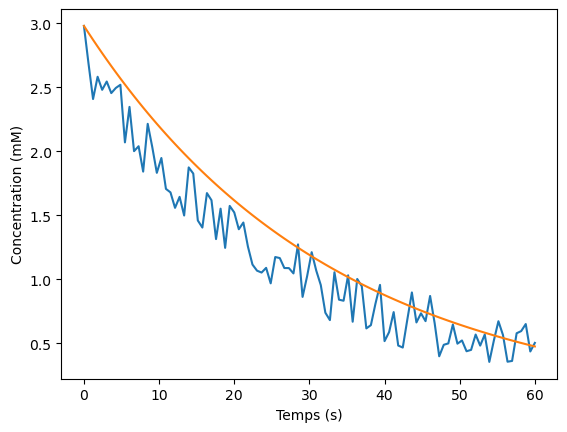

In [3]:
from pylab import * 

# Generating data with noise
t = linspace(0, 60, 100) 
A = 2.5*exp(-0.04*t) + 0.5*random(100)

# Adjustment of ln(A), log(A) note in python:
from numpy.polynomial import polynomial as poly   
p = poly.polyfit( t, log(A), deg=1 )                 # linear adjustment with t on the abscissa and log(A) on the ordinate
print("The coefficients of the polynomial are:", p)
k = -p[1]                                            # k is minus the slope

y = A[0]*exp(-k*t)                                   # y is an array of values ​​based on the model

# Trace
plot(t, A, label='A')
plot(t, y, label='modele 1er ordre')
xlabel('Temps (s)')
ylabel('Concentration (mM)')


NB: there are other Python modules offering linear regressions. A little later you will see the use of sklearn.linear_model.LinearRegression in data analysis.  


The third example below shows how to do this for a polynomial of order 2:

Les coefficients du polynome sont :  [ 1.68423514  2.82994994 -1.1878173 ]


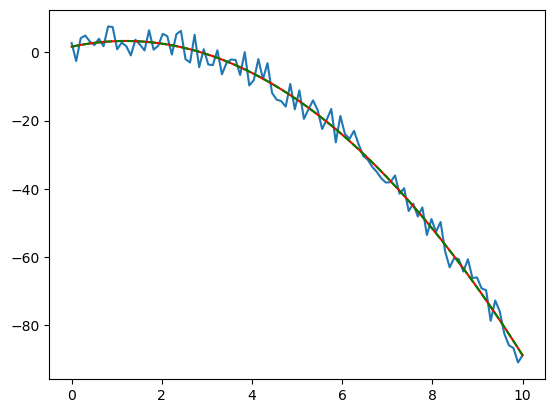

In [8]:
from pylab import *

# Reading and tracing data
t = linspace(0,10,100)
C = 1.06 + 3.25*t - 1.23*t**2 + (random(len(t))-0.5)*10
plot(t, C)

# Adjustment of A
from numpy.polynomial import polynomial as poly   
p = poly.polyfit( t, C, deg=2 )
print("The coefficients of the polynomial are:", p)

y = poly.polyval( t, p )
z = p[0] + t*p[1] + t**2*p[2]

plot(t, y, 'r')
plot(t, z, '--g')



### Fitting an arbitrary function

Sometimes we want to find the parameters of a model that is neither a line nor a polynomial. 

In this case we first create a function which will return the values ​​of the model according to the variable and the parameters, then we use curve_fit from the scipy.optimize module to find which are the optimal parameters which allows this model to be best adjusted to the data. 

If the data is in the form of an array of abscissas $t$ and ordinates $C$ as in the example above, and the model function is called $f$, the syntax of curve_fit is: 

```
from scipy.optimize import curve_fit 
parametres_optimaux, erreurs = curve_fit( f , t , C, estimation_parametres) 

```

with estimation_parameters a table of initial values for the search for optimal parameters, parameters_optimals a table bringing together the optimized parameters, and errors a table giving the difference between the optimized model and the data. 

Below, we take the example of a polynomial fit but using curve_fit:

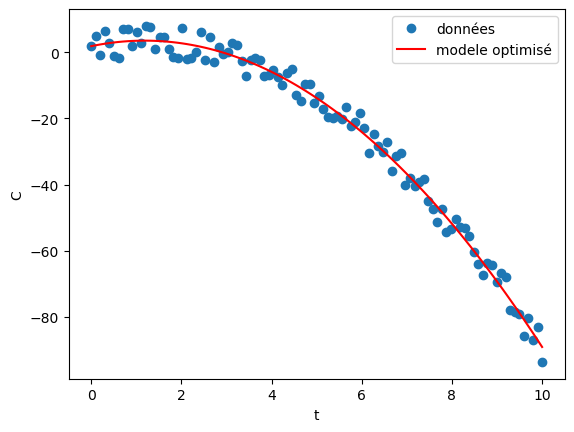

In [13]:
from pylab import *

# Creation of dummy data
t = linspace(0,10,100)
C = 1.06 + 3.25*t - 1.23*t**2 + (random(len(t))-0.5)*10

# Creation of a function depending on the variable (t) and 3 parameters (a, b, c)
# which returns the value of the model
def f(t,a,b,c):
    return a + b*t + c*t**2 

# Loading curve_fit
from scipy.optimize import curve_fit
# Call of curve fir with "f" as function, "t, C" as set of abscissas and ordinates,
# and (1,3,1) as initial values ​​for the search for optimal values ​​of a, b, and c.
parametres_optimaux, erreurs = curve_fit( f , t, C, (1,3,1) )
# separation of the 3 values ​​in the optimal parameters table into 3 variables aopt, bopt, copt
aopt, bopt, copt = parametres_optimaux

# Trace
figure() 
plot(t, C, 'o', label="données")                                  # data plot
plot(t, modeleC(t,aopt,bopt,copt), '-r', label="modele optimisé") # Optimized model layout
xlabel('t')
ylabel('C')
legend() 

Let's take the example of the data in the Concentrations.txt file. It is a kinetic chemical reaction corresponding to 
$$ A+B\rightarrow C$$
We wonder if this reaction can be modeled with kinetics: 
$$\frac{dC}{dt}=kAB$$
We can define $x(t)$ such that $C(t)=x(t)$, $A(t)=A_0-x(t)$ and $B(t)=B_0-x(t)$. The solution to the previous equation is 
$$x(t)=A_0\frac{1-e^{(A_0-B_0)kt}}{1-\frac{A_0}{B_0}e^{(A_0-B_0)kt}}$$
In the example below, we define this model in a function `x(t,k)` and use the `curve_fit` function of `scipy.optimize` to find the best value of $k$ possible to reproduce the data from the Concentrations.txt file.

L'ordre de la reaction deduit des donnees est :  0.994180162035747


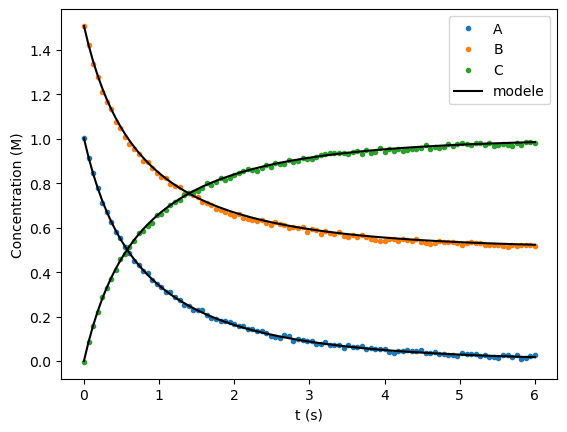

In [14]:
from pylab import *
t, A, B, C = genfromtxt('Concentrations.txt', unpack=True)
plot(t, A, '.', label='A')
plot(t, B, '.', label='B')
plot(t, C, '.', label='C')
A0 = A[0]
B0 = B[0]

# We define the model function with as first argument the variable which corresponds to the x-coordinates on a graph.
# Here it is time t. The following argument(s) are the adjustable parameters, here the constant k.
def x(t,k):
    tt = (A0-B0)*k*t
    return A0*(1-exp(tt))/(1-A0/B0*exp(tt))

from scipy.optimize import curve_fit
# the syntax is curve_fit(function serving as a model, table of abscissa data, table of ordered data, estimation of the value of the parameter(s) to be determined)
x_experimental = A0-A 
parametres_optimises, erreurs = curve_fit(x, t, x_experimental, 0.8)

# The optimized_parameters variable is a list, even if there is only one parameter to adjust like here. We therefore have parametres_optimises = [k].
k_optimal = parametres_optimises[0]

print("The order of the reaction deduced from the data is:", k_optimal)

# We generate curves based on the optimized model
modele_A = A0-x(t,k_optimal) 
modele_B = B0-x(t,k_optimal) 
modele_C = x(t,k_optimal) 

# Graph
plot(t, modele_A, '-k')
plot(t, modele_B, '-k')
plot(t, modele_C, '-k', label='modele')
xlabel('t (s)')
ylabel('Concentration (M)')
legend()

In [7]:
# ##########################################################################################
# delete this cell if you run this notebook outside of the CHIM2-ON1 distribution #
# ##########################################################################################

vID.end(cwd0)

**Fin à:** Wednesday 09 November 2022, 11:42:25  
**Durée:** 00:00:04 386ms

<p style="text-align: center"><img width="800px" src="./config/svg/logoFin.svg" style="margin-left:auto; margin-right:auto"/></p>